In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, roc_auc_score, roc_curve)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import joblib

In [2]:
df = pd.read_csv(r"C:\Users\mibra\OneDrive\Desktop\DL Project\online_gaming_behavior_expanded.csv")
print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Dataset shape: (100034, 13)
Columns: ['PlayerID', 'Age', 'Gender', 'Location', 'GameGenre', 'PlayTimeHours', 'InGamePurchases', 'GameDifficulty', 'SessionsPerWeek', 'AvgSessionDurationMinutes', 'PlayerLevel', 'AchievementsUnlocked', 'EngagementLevel']


,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,9000,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,25,Medium
1,9001,29,Female,USA,Strategy,5.525961,0,Medium,5,144,11,10,Medium
2,9002,22,Female,USA,Sports,8.223755,0,Easy,16,142,35,41,High
3,9003,35,Male,USA,Action,5.265351,1,Easy,9,85,57,47,Medium
4,9004,33,Male,Europe,Action,15.531945,0,Medium,2,131,95,37,Medium


In [3]:
print("Dataset Info:")
df.info()
print("\nNull values:", df.isnull().sum().sum())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100034 entries, 0 to 100033
Data columns (total 13 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   PlayerID                   100034 non-null  int64  
 1   Age                        100034 non-null  int64  
 2   Gender                     100034 non-null  object 
 3   Location                   100034 non-null  object 
 4   GameGenre                  100034 non-null  object 
 5   PlayTimeHours              100034 non-null  float64
 6   InGamePurchases            100034 non-null  int64  
 7   GameDifficulty             100034 non-null  object 
 8   SessionsPerWeek            100034 non-null  int64  
 9   AvgSessionDurationMinutes  100034 non-null  int64  
 10  PlayerLevel                100034 non-null  int64  
 11  AchievementsUnlocked       100034 non-null  int64  
 12  EngagementLevel            100034 non-null  object 
dtypes: float64(1), 

In [4]:
df.describe()

,PlayerID,Age,PlayTimeHours,InGamePurchases,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked
count,100034.000000,100034.000000,100034.000000,100034.000000,100034.000000,100034.000000,100034.000000,100034.00000
mean,59016.500000,32.028920,11.997100,0.201831,9.239818,94.831877,49.491273,24.20552
std,28877.472751,10.064491,6.918623,0.401369,5.494536,46.958636,27.232343,13.76397
min,9000.000000,15.000000,0.000115,0.000000,0.000000,10.000000,1.000000,0.00000
25%,34008.250000,23.000000,6.020737,0.000000,5.000000,58.000000,28.000000,13.00000
50%,59016.500000,32.000000,11.998474,0.000000,9.000000,96.000000,49.000000,24.00000
75%,84024.750000,41.000000,17.951153,0.000000,14.000000,132.000000,71.000000,35.00000
max,109033.000000,49.000000,23.999592,1.000000,19.000000,179.000000,99.000000,49.00000


In [5]:
df['ChurnRisk'] = df['EngagementLevel'].apply(lambda x: 1 if x == 'Low' else 0)
print("ChurnRisk distribution:")
print(df['ChurnRisk'].value_counts())
print(f"Churn rate: {df['ChurnRisk'].mean():.2%}")

ChurnRisk distribution:
ChurnRisk
0    74239
1    25795
Name: count, dtype: int64
Churn rate: 25.79%


In [6]:
X_raw = df.drop(['PlayerID','EngagementLevel','ChurnRisk'], axis=1).copy()
y     = df['ChurnRisk']

for col in ['Gender','Location','GameGenre','GameDifficulty']:
    X_raw[col] = LabelEncoder().fit_transform(X_raw[col])

selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X_raw, y)

feature_scores = pd.DataFrame({
    'Feature': X_raw.columns,
    'F_Score': selector.scores_.round(2),
    'P_Value': selector.pvalues_.round(6)
}).sort_values('F_Score', ascending=False).reset_index(drop=True)

print("Feature Importance Scores (ANOVA F-Test):")
print(feature_scores.to_string(index=False))

Feature Importance Scores (ANOVA F-Test):
                  Feature  F_Score  P_Value
          SessionsPerWeek 32877.57 0.000000
AvgSessionDurationMinutes 12639.80 0.000000
              PlayerLevel   530.74 0.000000
     AchievementsUnlocked   520.17 0.000000
          InGamePurchases     1.96 0.161445
                      Age     1.06 0.303789
                GameGenre     0.99 0.320001
            PlayTimeHours     0.62 0.430066
           GameDifficulty     0.46 0.497855
                   Gender     0.35 0.551649
                 Location     0.00 0.958584


In [7]:
SELECTED_FEATURES = ['SessionsPerWeek', 'AvgSessionDurationMinutes',
                     'PlayerLevel', 'AchievementsUnlocked']

X = df[SELECTED_FEATURES].copy()
y = df['ChurnRisk'].copy()

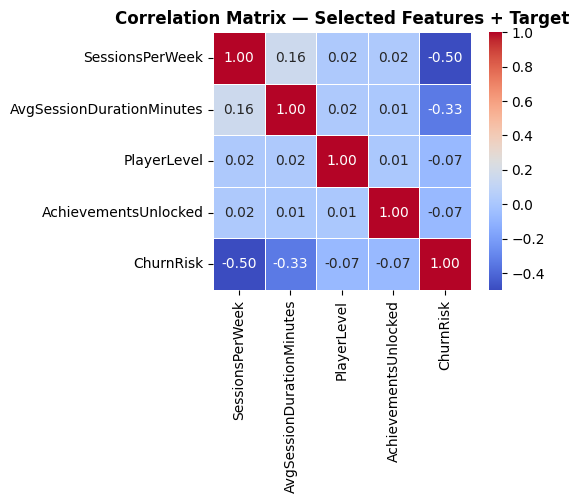

In [8]:
plt.figure(figsize=(6, 5))
corr_df = X.copy()
corr_df['ChurnRisk'] = y
sns.heatmap(corr_df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Correlation Matrix — Selected Features + Target', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)


In [10]:
def build_dnn(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),

        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.35),

        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.25),

        layers.Dense(32, activation='relu'),
        layers.Dropout(0.2),

        layers.Dense(1, activation='sigmoid')
    ], name="Churn")

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.AUC(name='auc'),
                 keras.metrics.Precision(name='precision'),
                 keras.metrics.Recall(name='recall')]
    )
    return model

model = build_dnn(X_train_sc.shape[1])
model.summary()

Model: "Churn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,337 (181.00 KB)

 Trainable params: 45,441 (177.50 KB)

 Non-trainable params: 896 (3.50 KB)

In [11]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=12,
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=5, min_lr=1e-6, verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath='best_churn_model.keras',
        monitor='val_auc', mode='max',
        save_best_only=True, verbose=0
    )
]

In [12]:
history = model.fit(
    X_train_sc, y_train,
    epochs=120,
    batch_size=512,
    validation_split=0.15,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/120
133/133 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.8110 - auc: 0.8421 - loss: 0.4319 - precision: 0.6301 - recall: 0.6454 - val_accuracy: 0.7514 - val_auc: 0.8735 - val_loss: 0.4352 - val_precision: 0.8743 - val_recall: 0.0470 - learning_rate: 0.0010
Epoch 2/120
133/133 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.8422 - auc: 0.8672 - loss: 0.3872 - precision: 0.7168 - recall: 0.6409 - val_accuracy: 0.7888 - val_auc: 0.8783 - val_loss: 0.4171 - val_precision: 0.8433 - val_recall: 0.2268 - learning_rate: 0.0010
Epoch 3/120
133/133 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.8482 - auc: 0.8724 - loss: 0.3774 - precision: 0.7276 - recall: 0.6565 - val_accuracy: 0.8325 - val_auc: 0.8797 - val_loss: 0.3862 - val_precision: 0.7948 - val_recall: 0.4760 - learning_rate: 0.0010
Epoch 4/120
133/133 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.8510 - auc: 0.8746 - loss: 0.3728 - precision: 0.7313 - recall: 0.6669 - val_accuracy: 0.8520 - val_auc: 0.8821 - val_loss: 0.3

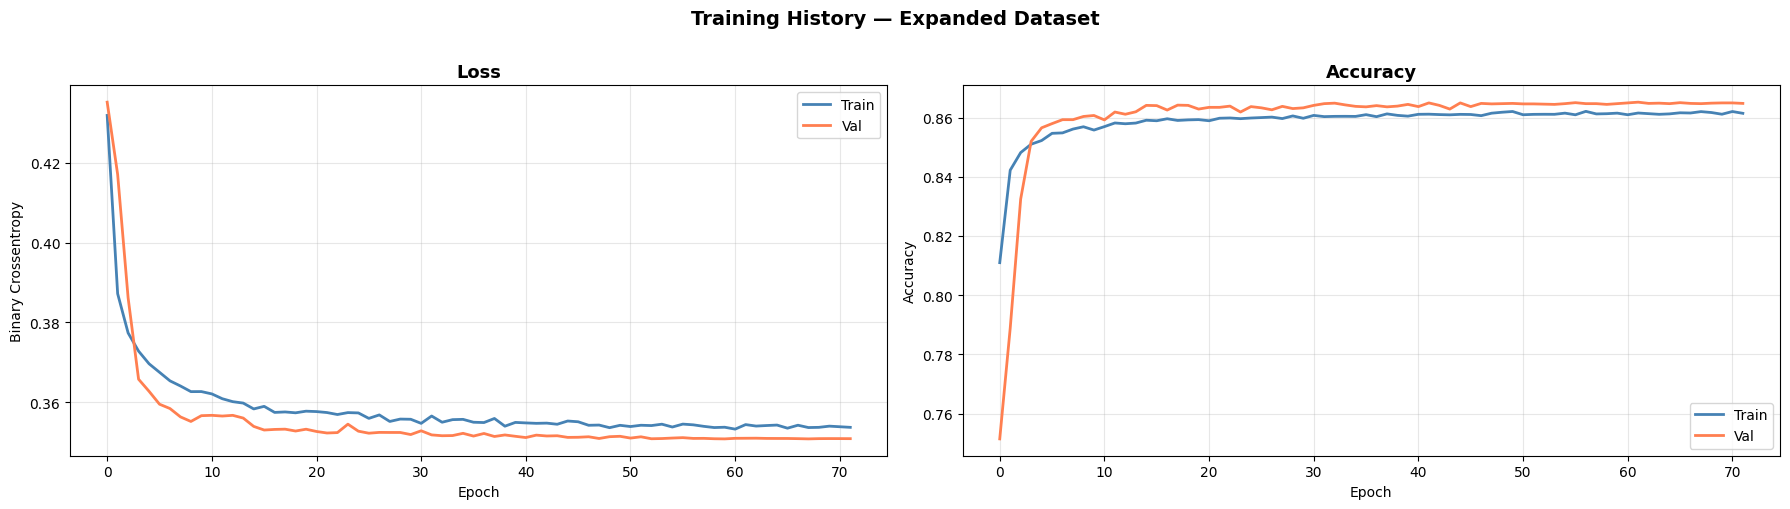

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

axes[0].plot(history.history['loss'],     label='Train', color='steelblue', lw=2)
axes[0].plot(history.history['val_loss'], label='Val',   color='coral',     lw=2)
axes[0].set_title('Loss',     fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Binary Crossentropy')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['accuracy'],     label='Train', color='steelblue', lw=2)
axes[1].plot(history.history['val_accuracy'], label='Val',   color='coral',     lw=2)
axes[1].set_title('Accuracy', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Training History — Expanded Dataset', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Accuracy : 0.8627 (86.27%)
AUC-ROC  : 0.8854


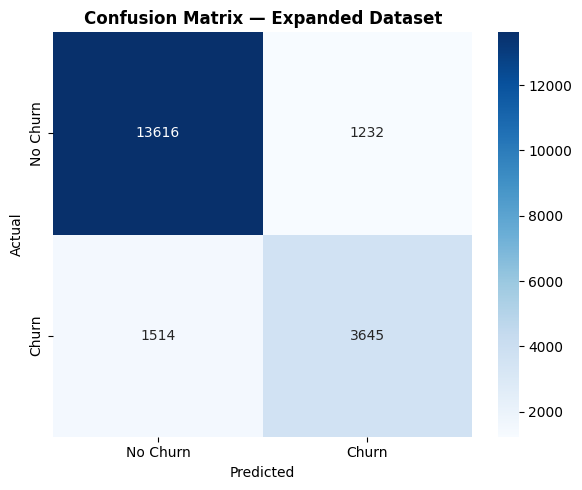

In [21]:
y_pred_prob = model.predict(X_test_sc, verbose=0).flatten()
y_pred      = (y_pred_prob > 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)

print(f"Accuracy : {acc:.4f} ({acc:.2%})")
print(f"AUC-ROC  : {auc:.4f}")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix — Expanded Dataset', fontsize=12, fontweight='bold')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout()
plt.show()


In [15]:
print("Classification Report")
print("─" * 55)
print(classification_report(y_test, y_pred, target_names=['No Churn (0)','Churn (1)']))

Classification Report
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

No Churn (0)       0.90      0.92      0.91     14848
   Churn (1)       0.75      0.71      0.73      5159

    accuracy                           0.86     20007
   macro avg       0.82      0.81      0.82     20007
weighted avg       0.86      0.86      0.86     20007



In [16]:
model.save("churn.keras")
joblib.dump(scaler,            "scaler.pkl")
joblib.dump(SELECTED_FEATURES, "features.pkl")


['features.pkl']

In [17]:
import gradio as gr
import joblib, numpy as np, tensorflow as tf

_model    = tf.keras.models.load_model("churn.keras")
_scaler   = joblib.load("scaler.pkl")
_features = joblib.load("features.pkl")

def predict_churn(sessions_per_week, avg_session_duration, player_level, achievements):
    arr    = np.array([[sessions_per_week, avg_session_duration, player_level, achievements]])
    scaled = _scaler.transform(arr)
    prob   = float(_model.predict(scaled, verbose=0)[0][0])

    if prob > 0.70:
        risk, rec = "🔴 HIGH RISK",    "Offer immediate discounts or exclusive in-game rewards"
    elif prob > 0.40:
        risk, rec = "🟡 MEDIUM RISK",  "Send personalized missions and push reminders"
    else:
        risk, rec = "🟢 LOW RISK",     "Maintain engagement with loyalty rewards"

    bar = "█" * int(prob * 20) + "░" * (20 - int(prob * 20))
    summary = f"{risk}\n\nProbability : {prob:.1%}\n[{bar}]\n\nRecommendation:\n{rec}"
    return round(prob, 4), summary

app = gr.Interface(
    fn=predict_churn,
    inputs=[
        gr.Slider(0,  19,  value=5,  step=1, label="Sessions Per Week"),
        gr.Slider(10, 179, value=60, step=5, label="Avg Session Duration (Minutes)"),
        gr.Slider(1,  99,  value=30, step=1, label="Player Level"),
        gr.Slider(0,  49,  value=15, step=1, label="Achievements Unlocked"),
    ],
    outputs=[
        gr.Number(label="Churn Probability (0–1)"),
        gr.Textbox(label="Risk Assessment & Recommendation", lines=7),
    ],
    title="🎮 Player Churn Risk Prediction",
    description="Deep Neural Network trained on 100,034 player records. Adjust the sliders to predict churn risk.",
    examples=[[2,15,5,5],[10,90,40,20],[18,160,80,45]],
    theme=gr.themes.Soft()
)
app.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
